# Emotion Classification in Texts using Traditional Machine Learning

This implementation classifies text into five emotion categories (joy, sadness, anger, fear, neutral) using TF-IDF vectorization and multiple classifiers including:
* Naive Bayes
* Logistic Regression
* Random Forest
* SVM.

The pipeline covers text preprocessing, feature extraction, model training, and evaluation using F1 scores and confusion matrices.

In [9]:
# Importing preparation

# mathematics
import pandas as pd
import numpy as np

# text preprocessing
import re

# plots and metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from typing import List, Optional

# feature extraction / vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# classifiers
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# save and load a file
import pickle

import warnings
warnings.filterwarnings('ignore')

# Import Datasets

Text-Emotion Dataset was split into training 70% and testing 30%

In [10]:
# The two sets both consist of Emotion Column and Text Column.

df_train = pd.read_csv('data/data_train.csv')
df_test = pd.read_csv('data/data_test.csv')

X_train = df_train.Text
X_test = df_test.Text

y_train = df_train.Emotion
y_test = df_test.Emotion

class_names = ['joy', 'sadness', 'anger', 'neutral', 'fear']
data = pd.concat([df_train, df_test])

print('size of training set: %s' % (len(df_train['Text'])))
print('size of validation set: %s' % (len(df_test['Text'])))
print(data.Emotion.value_counts())

data.head()

size of training set: 7934
size of validation set: 3393
Emotion
joy        2326
sadness    2317
anger      2259
neutral    2254
fear       2171
Name: count, dtype: int64


,Emotion,Text
0,neutral,There are tons of other paintings that I thin...
1,sadness,"Yet the dog had grown old and less capable , a..."
2,fear,When I get into the tube or the train without ...
3,fear,This last may be a source of considerable disq...
4,anger,She disliked the intimacy he showed towards so...


In [11]:
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, 
                          classes: List[str], normalize: bool = False, 
                          title: Optional[str] = None, 
                          cmap: plt.cm = plt.cm.Blues, 
                          figsize: tuple = (10, 7)) -> plt.Axes:

    # 1. Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # 2. Apply normalization if requested
    if normalize:
        # Avoid division by zero by adding a small constant to the denominator
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)
        default_title = "Normalized Confusion Matrix"
        value_format = '.2f'
    else:
        default_title = "Confusion Matrix"
        value_format = 'd'
    
    # Use provided title or the default one
    plot_title = title if title is not None else default_title

    # 3. Create the visualization
    plt.figure(figsize=figsize)
    
    # Use Seaborn's heatmap for a cleaner and more styled plot
    ax = sns.heatmap(cm,
                     annot=True,           # Annotate cells with the value
                     fmt=value_format,     # String formatting of annotations
                     cmap=cmap,
                     xticklabels=classes,
                     yticklabels=classes,
                     cbar_kws={'label': 'Scale'},
                     square=True)          # Try to make cells square

    # 4. Set labels and title
    ax.set_title(plot_title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)

    # 5. Improve tick labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Keep y-axis labels horizontal

    # 6. Tight layout for a professional look
    plt.tight_layout()
    
    return ax


# Text Preprocessing

In [12]:
import spacy
# Load spaCy pretraining model
nlp = spacy.load("en_core_web_sm")

def preprocess_and_tokenize(data):
    # Remove HTML notes
    data = re.sub("(<.*?>)", "", data)

    # Remove URL
    data = re.sub(r'http\S+', '', data)
    
    # Remove hashtags and @names
    data = re.sub(r"(#[\d\w\.]+)", '', data)
    data = re.sub(r"(@[\d\w\.]+)", '', data)

    # Remove punctuations and non-ASCII numbers
    data = re.sub("(\\W|\\d)", " ", data)
    
    doc = nlp(data)
    
    processed_tokens = []
    
    for token in doc:
        # Remove punctuations, spaces, numbers and stop words
        if not token.is_punct and not token.is_space and not token.is_digit and not token.is_stop and \
           len(token.text.strip()) > 1: # Extract strings that length shorter or equal to 1
            processed_tokens.append(token.lemma_.lower())
            
    return processed_tokens

# Text Representation

In [13]:
# TFIDF, unigrams and bigrams
vect = TfidfVectorizer(tokenizer=preprocess_and_tokenize, 
                       sublinear_tf=True, norm='l2',    # L2 normalization
                       ngram_range=(1, 2),              # Unigram and Bigram
                       min_df=2,                        # Ignore terms that appear in < 2 documents
                       max_df=0.95,                     # Ignore terms that appear in > 95% of documents
                       stop_words='english')            

# fit on our complete corpus
vect.fit_transform(data.Text)

# transform testing and training datasets to vectors
X_train_vect = vect.transform(X_train)
X_test_vect = vect.transform(X_test)

# Classifiers

### Naive Bayes


Accuracy (Naive Bayes): 62.81%

F1 Score (Naive Bayes): 62.81

Naive Bayes Confusion Matrix:
 [[453  59  57  47  77]
 [ 62 474  55  28  60]
 [ 40  36 476  88  67]
 [ 46  39  78 258 217]
 [ 70  49  58  29 470]]


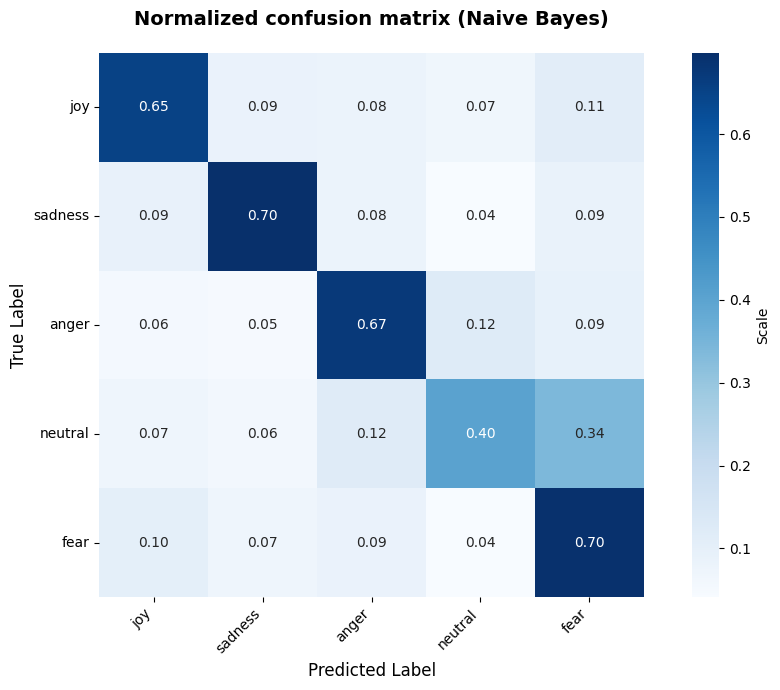

In [14]:
nb = MultinomialNB()

nb.fit(X_train_vect, y_train)

ynb_pred = nb.predict(X_test_vect)

nb_accuracy = accuracy_score(y_test, ynb_pred) * 100
nb_f1_score = f1_score(y_test, ynb_pred, average='micro') * 100

print("\nAccuracy (Naive Bayes): {:.2f}%".format(nb_accuracy))
print("\nF1 Score (Naive Bayes): {:.2f}".format(nb_f1_score))
print("\nNaive Bayes Confusion Matrix:\n", confusion_matrix(y_test, ynb_pred))

# Plot normalized confusion matrix
plot_confusion_matrix(y_test, ynb_pred, classes=class_names, normalize=True, title='Normalized confusion matrix (Naive Bayes)')
plt.show()

### Random Forest


Accuracy (Random Forest): 65.55%

F1 Score (Random Forest): 65.55

Random Forest Confusion Matrix:
 [[413  66  48 103  63]
 [ 73 430  33  83  60]
 [ 56  32 449 133  37]
 [ 38  21  54 493  32]
 [ 70  42  45  80 439]]


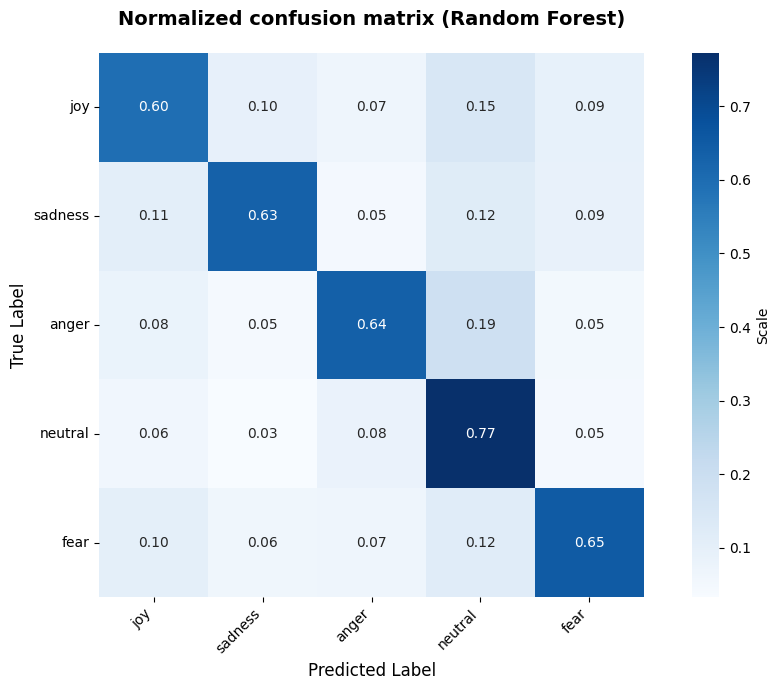

In [15]:
rf = RandomForestClassifier(n_estimators=50)
rf.fit(X_train_vect, y_train)

yrf_pred = rf.predict(X_test_vect)

rf_accuracy = accuracy_score(y_test, yrf_pred) * 100
rf_f1_score = f1_score(y_test, yrf_pred, average='micro') * 100

print("\nAccuracy (Random Forest): {:.2f}%".format(rf_accuracy))
print("\nF1 Score (Random Forest): {:.2f}".format(rf_f1_score))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, yrf_pred))

plot_confusion_matrix(y_test, yrf_pred, classes=class_names, normalize=True, title='Normalized confusion matrix (Random Forest)')
plt.show()

###  Logistic Regression


Accuracy (Logistic Regression): 68.41%

F1 Score (Logistic Regression): 68.41

Logistic Regression Confusion Matrix:
 [[456  56  47  95  39]
 [ 55 489  39  60  36]
 [ 50  35 457 132  33]
 [ 35  34  59 467  43]
 [ 75  50  43  56 452]]


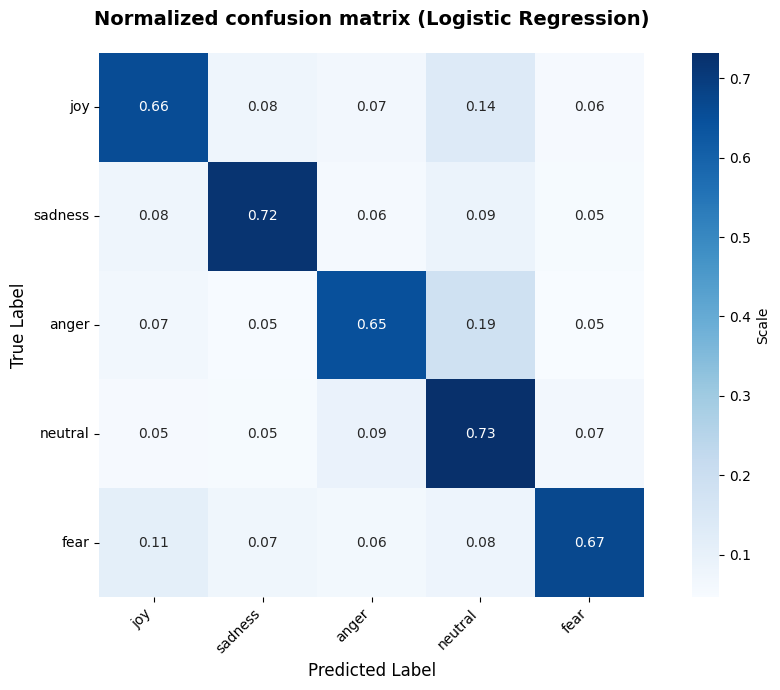

In [16]:
log = LogisticRegression(solver='lbfgs', max_iter=200)
log.fit(X_train_vect, y_train)

ylog_pred = log.predict(X_test_vect)

log_accuracy = accuracy_score(y_test, ylog_pred) * 100
log_f1_score = f1_score(y_test, ylog_pred, average='micro') * 100

print("\nAccuracy (Logistic Regression): {:.2f}%".format(log_accuracy))
print("\nF1 Score (Logistic Regression): {:.2f}".format(log_f1_score))
print("\nLogistic Regression Confusion Matrix:\n", confusion_matrix(y_test, ylog_pred))

plot_confusion_matrix(y_test, ylog_pred, classes=class_names, normalize=True, title='Normalized confusion matrix (Logistic Regression)')
plt.show()

###  Linear Support Vector Classifier


Accuracy (Linear SVC): 67.40%

F1 Score (Linear SVC): 67.40

Linear SVC Confusion Matrix:
 [[442  45  45 118  43]
 [ 61 467  33  78  40]
 [ 46  43 440 146  32]
 [ 38  28  48 489  35]
 [ 73  44  36  74 449]]


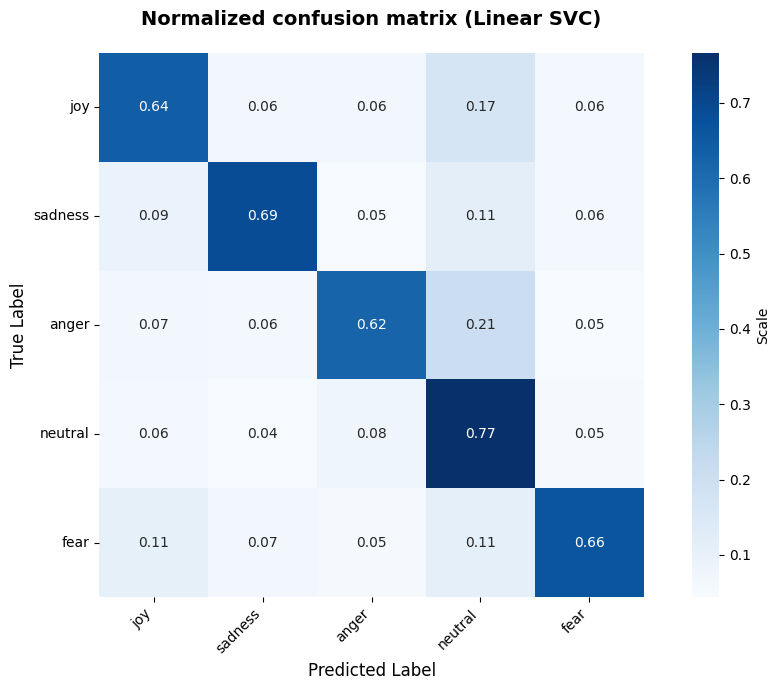

In [17]:
svc = SVC(tol=1e-05,
          C=1.0,        # Regularization parameter
          kernel='linear', 
          probability=True)

svc.fit(X_train_vect, y_train)

ysvm_pred = svc.predict(X_test_vect)

svc_accuracy = accuracy_score(y_test, ysvm_pred) * 100
svc_f1_score = f1_score(y_test, ysvm_pred, average='micro') * 100

print("\nAccuracy (Linear SVC): {:.2f}%".format(svc_accuracy))
print("\nF1 Score (Linear SVC): {:.2f}".format(svc_f1_score))
print("\nLinear SVC Confusion Matrix:\n", confusion_matrix(y_test, ysvm_pred))

plot_confusion_matrix(y_test, ysvm_pred, classes=class_names, normalize=True, title='Normalized confusion matrix (Linear SVC)')
plt.show()

### F1 Score Summary

In [18]:
data = {
    'Approach': ['Naive Bayes', 'Random Forrest', 'Logistic Regression', 'SVM'],
    'F1-Score': [nb_f1_score, rf_f1_score, log_f1_score, svc_f1_score]
}
df = pd.DataFrame(data)

df

,Approach,F1-Score
0,Naive Bayes,62.805777
1,Random Forrest,65.546714
2,Logistic Regression,68.405541
3,SVM,67.403478


### TF-IDF and SVM Model

In [19]:
def create_emotion_classifier_pipeline(classifier):
    """
    Creates a complete pipeline for emotion classification.
    The pipeline handles both feature extraction and prediction.
    """
    emotion_pipeline = Pipeline([
        ('tfidf_vectorizer', vect),
        ('classifier', classifier)
    ])
    return emotion_pipeline

def save_emotion_model(pipeline, filepath):
    """Saves the trained emotion classification pipeline."""
    with open(filepath, 'wb') as model_file:
        pickle.dump(pipeline, model_file)

models = {'naive_bayes': nb, 
          'random_forest': rf, 
          'logistic_regression': log, 
          'svm': svc}

for model_name, model in models.items():
    classifier_pipeline = create_emotion_classifier_pipeline(model)
    classifier_pipeline.fit(X_train, y_train)
    
    save_path = f'models/tfidf_{model_name}.sav'
    save_emotion_model(classifier_pipeline, save_path)
    print(f"Saved {model_name} model to {save_path}")

def predict_emotion(text_message, model_path):
    """Loads the model and predicts emotion for a given text."""
    with open(model_path, 'rb') as model_file:
        loaded_model = pickle.load(model_file)
    
    prediction = loaded_model.predict([text_message])
    probabilities = loaded_model.predict_proba([text_message])

    # print("训练时的类别顺序:", y_train.unique())
    # print("模型学习的类别顺序:", loaded_model.classes_)
    
    return prediction[0], probabilities[0]


Saved naive_bayes model to models/tfidf_naive_bayes.sav
Saved random_forest model to models/tfidf_random_forest.sav
Saved logistic_regression model to models/tfidf_logistic_regression.sav
Saved svm model to models/tfidf_svm.sav


In [20]:
message = 'delivery was hour late and my pizza is cold!'
emotion, confidence_scores = predict_emotion(message, 'models/tfidf_logistic_regression.sav')
print(f"Message: '{message}'")
print(f"Predicted emotion: {emotion}")
print(f"Confidence scores: {confidence_scores}\n")

message = 'what do you mean'
emotion, confidence_scores = predict_emotion(message, 'models/tfidf_logistic_regression.sav')
print(f"Message: '{message}'")
print(f"Predicted emotion: {emotion}")
print(f"Confidence scores: {confidence_scores}\n")

message = 'too young too simple'
emotion, confidence_scores = predict_emotion(message, 'models/tfidf_logistic_regression.sav')
print(f"Message: '{message}'")
print(f"Predicted emotion: {emotion}")
print(f"Confidence scores: {confidence_scores}\n")

message = 'I cant decide what to do now, he is a freak'
emotion, confidence_scores = predict_emotion(message, 'models/tfidf_logistic_regression.sav')
print(f"Message: '{message}'")
print(f"Predicted emotion: {emotion}")
print(f"Confidence scores: {confidence_scores}\n")

message = 'it is really awful'
emotion, confidence_scores = predict_emotion(message, 'models/tfidf_svm.sav')
print(f"Message: '{message}'")
print(f"Predicted emotion: {emotion}")
print(f"Confidence scores: {confidence_scores}\n")

Message: 'delivery was hour late and my pizza is cold!'
Predicted emotion: anger
Confidence scores: [0.41201493 0.24856194 0.09456337 0.15685693 0.08800282]

Message: 'what do you mean'
Predicted emotion: neutral
Confidence scores: [0.08738695 0.14412758 0.11041116 0.54220025 0.11587406]

Message: 'too young too simple'
Predicted emotion: neutral
Confidence scores: [0.16072899 0.15143413 0.2253756  0.32647853 0.13598275]

Message: 'I cant decide what to do now, he is a freak'
Predicted emotion: fear
Confidence scores: [0.08721324 0.43274965 0.07698833 0.19523637 0.20781241]

Message: 'it is really awful'
Predicted emotion: sadness
Confidence scores: [0.08106924 0.04467994 0.09076149 0.29293278 0.49055655]

